# 🚀 HPC Project 7 — Parallel Backtracking Algorithms

| # | Problem | Parallelization Strategy |
|---|---------|-------------------------|
| 1 | **N-Queens** | Each thread explores a different first-row column |
| 2 | **Sudoku Solver** | Threads try different digits for the first empty cell |
| 3 | **Traveling Salesman (TSP)** | Each thread starts from a different second city |

> ▶️ **How to run:** Click `Runtime` → `Run All`

---
## ⚙️ Step 1: Verify GCC + OpenMP

In [ ]:
!gcc --version
!echo '#include <omp.h>\n#include <stdio.h>\nint main(){printf("OpenMP OK. Threads available: %d\\n", omp_get_max_threads()); return 0;}' > /tmp/test.c
!gcc -fopenmp /tmp/test.c -o /tmp/test && /tmp/test

gcc (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0
Copyright (C) 2021 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

/tmp/test.c:1:17: warning: extra tokens at end of #include directive
    1 | #include <omp.h>\n#include <stdio.h>\nint main(){printf("OpenMP OK. Threads available: %d\\n", omp_get_max_threads()); return 0;}
      |                 ^
/usr/bin/ld: /usr/lib/gcc/x86_64-linux-gnu/11/../../../x86_64-linux-gnu/Scrt1.o: in function `_start':
(.text+0x1b): undefined reference to `main'
collect2: error: ld returned 1 exit status


---
## 👑 Problem 1: N-Queens Problem
Place N queens on an N×N board so no two queens attack each other.

**Parallel strategy:** Each thread takes a different column for row 0 and independently solves that branch.

In [ ]:
%%writefile /tmp/nqueens.c
#include <stdio.h>
#include <string.h>
#include <omp.h>

#define N 13

long long seq_solutions = 0;
long long par_solutions = 0;

int is_safe(int board[], int row, int col) {
    for (int i = 0; i < row; i++)
        if (board[i] == col ||
            board[i] - i == col - row ||
            board[i] + i == col + row) return 0;
    return 1;
}

void solve_seq(int board[], int row) {
    if (row == N) { seq_solutions++; return; }
    for (int c = 0; c < N; c++)
        if (is_safe(board, row, c)) {
            board[row] = c;
            solve_seq(board, row + 1);
        }
}

void solve_inner(int board[], int row, long long *count) {
    if (row == N) { (*count)++; return; }
    for (int c = 0; c < N; c++)
        if (is_safe(board, row, c)) {
            board[row] = c;
            solve_inner(board, row + 1, count);
        }
}

void solve_parallel() {
    long long total = 0;
    #pragma omp parallel for schedule(dynamic) reduction(+:total)
    for (int c = 0; c < N; c++) {
        int board[N];
        long long local = 0;
        board[0] = c;
        solve_inner(board, 1, &local);
        total += local;
    }
    par_solutions = total;
}

int main() {
    printf("\n==============================\n");
    printf("  N-Queens Problem (N = %d)\n", N);
    printf("==============================\n\n");

    int board[N];
    int threads = omp_get_max_threads();

    double t1 = omp_get_wtime();
    solve_seq(board, 0);
    double seq_t = omp_get_wtime() - t1;

    printf("[Sequential]\n");
    printf("  Solutions     : %lld\n", seq_solutions);
    printf("  Time taken    : %.4f seconds\n\n", seq_t);

    double t2 = omp_get_wtime();
    solve_parallel();
    double par_t = omp_get_wtime() - t2;

    printf("[Parallel] (%d threads)\n", threads);
    printf("  Solutions     : %lld\n", par_solutions);
    printf("  Time taken    : %.4f seconds\n\n", par_t);

    printf("[Performance]\n");
    printf("  Speedup       : %.2fx\n", seq_t / par_t);
    printf("  Efficiency    : %.2f%%\n", (seq_t / par_t / threads) * 100.0);
    printf("  Match         : %s\n", seq_solutions == par_solutions ? "YES CORRECT" : "NO ERROR");
    return 0;
}

Overwriting /tmp/nqueens.c


In [ ]:
!gcc -O2 -fopenmp -Wall -o /tmp/nqueens /tmp/nqueens.c && echo 'Compiled OK'
!OMP_NUM_THREADS=4 /tmp/nqueens

Compiled OK

  N-Queens Problem (N = 13)

[Sequential]
  Solutions     : 73712
  Time taken    : 1.4905 seconds

[Parallel] (4 threads)
  Solutions     : 73712
  Time taken    : 0.9288 seconds

[Performance]
  Speedup       : 1.60x
  Efficiency    : 40.12%
  Match         : YES CORRECT


---
## 🔢 Problem 2: Sudoku Solver
Fill a 9×9 grid following Sudoku rules using backtracking.

**Parallel strategy:** Try all valid digits for the first empty cell in parallel — each thread takes one digit and solves the rest independently.

!rm -f /tmp/sudoku /tmp/tsp /tmp/nqueens /tmp/sudoku.c /tmp/tsp.c
!echo "Cleaned"

In [ ]:
%%writefile /tmp/sudoku.c
#include <stdio.h>
#include <string.h>
#include <omp.h>

/* AI Escargot - world's hardest sudoku, takes 3-8s sequential */
int puzzle_hard[9][9] = {
    {1,0,0,0,0,7,0,9,0},
    {0,3,0,0,2,0,0,0,8},
    {0,0,9,6,0,0,5,0,0},
    {0,0,5,3,0,0,9,0,0},
    {0,1,0,0,8,0,0,0,2},
    {6,0,0,0,0,4,0,0,0},
    {3,0,0,0,0,0,0,1,0},
    {0,4,0,0,0,0,0,0,7},
    {0,0,7,0,0,0,3,0,0}
};

volatile int par_solved = 0;
int par_result[9][9];

void copy_board(int d[9][9], int s[9][9]) { memcpy(d, s, 81*sizeof(int)); }

void print_board(int b[9][9]) {
    printf("+-------+-------+-------+\n");
    for (int r = 0; r < 9; r++) {
        if (r == 3 || r == 6) printf("+-------+-------+-------+\n");
        printf("| ");
        for (int c = 0; c < 9; c++) {
            if (c == 3 || c == 6) printf("| ");
            printf(b[r][c] ? "%d " : ". ", b[r][c]);
        }
        printf("|\n");
    }
    printf("+-------+-------+-------+\n");
}

int is_valid(int b[9][9], int row, int col, int num) {
    for (int i = 0; i < 9; i++)
        if (b[row][i] == num || b[i][col] == num) return 0;
    int br=(row/3)*3, bc=(col/3)*3;
    for (int r=br; r<br+3; r++)
        for (int c=bc; c<bc+3; c++)
            if (b[r][c]==num) return 0;
    return 1;
}

int find_empty(int b[9][9], int *row, int *col) {
    for (*row=0; *row<9; (*row)++)
        for (*col=0; *col<9; (*col)++)
            if (b[*row][*col]==0) return 1;
    return 0;
}

int solve_seq(int b[9][9]) {
    int row, col;
    if (!find_empty(b, &row, &col)) return 1;
    for (int n=1; n<=9; n++)
        if (is_valid(b, row, col, n)) {
            b[row][col] = n;
            if (solve_seq(b)) return 1;
            b[row][col] = 0;
        }
    return 0;
}

int solve_worker(int b[9][9]) {
    if (par_solved) return 0;
    int row, col;
    if (!find_empty(b, &row, &col)) return 1;
    for (int n=1; n<=9; n++) {
        if (par_solved) return 0;
        if (is_valid(b, row, col, n)) {
            b[row][col] = n;
            if (solve_worker(b)) return 1;
            b[row][col] = 0;
        }
    }
    return 0;
}

void solve_parallel(int puzzle[9][9]) {
    par_solved = 0;
    int row=0, col=0;
    find_empty(puzzle, &row, &col);
    #pragma omp parallel for schedule(dynamic,1) num_threads(4) \
        shared(par_solved, par_result)
    for (int n=1; n<=9; n++) {
        if (par_solved) continue;
        if (!is_valid(puzzle, row, col, n)) continue;
        int local[9][9];
        copy_board(local, puzzle);
        local[row][col] = n;
        if (solve_worker(local)) {
            #pragma omp critical
            {
                if (!par_solved) {
                    par_solved = 1;
                    copy_board(par_result, local);
                }
            }
        }
    }
}

int main() {
    printf("\n==============================\n");
    printf("  Sudoku: Hard Puzzle\n");
    printf("==============================\n\n");

    int board[9][9];
    copy_board(board, puzzle_hard);
    int threads = omp_get_max_threads();

    double t1    = omp_get_wtime();
    int ok       = solve_seq(board);
    double seq_t = omp_get_wtime() - t1;
    printf("[Sequential]\n");
    printf("  Solved        : %s\n", ok ? "YES" : "NO");
    printf("  Time taken    : %.4f seconds\n\n", seq_t);
    if (ok) print_board(board);

    par_solved = 0;
    double t2    = omp_get_wtime();
    solve_parallel(puzzle_hard);
    double par_t = omp_get_wtime() - t2;
    printf("[Parallel] (%d threads)\n", threads);
    printf("  Solved        : %s\n", par_solved ? "YES" : "NO");
    printf("  Time taken    : %.4f seconds\n\n", par_t);
    if (par_solved) print_board(par_result);

    printf("[Performance]\n");
    printf("  Speedup       : %.2fx\n", seq_t / par_t);
    printf("  Efficiency    : %.2f%%\n\n", (seq_t / par_t / threads) * 100.0);
    return 0;
}

Overwriting /tmp/sudoku.c


In [ ]:
!gcc -O2 -fopenmp -Wall -o /tmp/sudoku /tmp/sudoku.c && echo 'Compiled OK'
!OMP_NUM_THREADS=4 /tmp/sudoku

Compiled OK

  Sudoku: Hard Puzzle

[Sequential]
  Solved        : YES
  Time taken    : 0.0015 seconds

+-------+-------+-------+
| 1 6 2 | 8 5 7 | 4 9 3 |
| 5 3 4 | 1 2 9 | 6 7 8 |
| 7 8 9 | 6 4 3 | 5 2 1 |
+-------+-------+-------+
| 4 7 5 | 3 1 2 | 9 8 6 |
| 9 1 3 | 5 8 6 | 7 4 2 |
| 6 2 8 | 7 9 4 | 1 3 5 |
+-------+-------+-------+
| 3 5 6 | 4 7 8 | 2 1 9 |
| 2 4 1 | 9 3 5 | 8 6 7 |
| 8 9 7 | 2 6 1 | 3 5 4 |
+-------+-------+-------+
[Parallel] (4 threads)
  Solved        : YES
  Time taken    : 0.0008 seconds

+-------+-------+-------+
| 1 6 2 | 8 5 7 | 4 9 3 |
| 5 3 4 | 1 2 9 | 6 7 8 |
| 7 8 9 | 6 4 3 | 5 2 1 |
+-------+-------+-------+
| 4 7 5 | 3 1 2 | 9 8 6 |
| 9 1 3 | 5 8 6 | 7 4 2 |
| 6 2 8 | 7 9 4 | 1 3 5 |
+-------+-------+-------+
| 3 5 6 | 4 7 8 | 2 1 9 |
| 2 4 1 | 9 3 5 | 8 6 7 |
| 8 9 7 | 2 6 1 | 3 5 4 |
+-------+-------+-------+
[Performance]
  Speedup       : 1.90x
  Efficiency    : 47.52%



---
## 🗺️ Problem 3: Traveling Salesman Problem (TSP)
Find the shortest route that visits all cities exactly once and returns to start.

**Parallel strategy:** Each thread starts from a different second city and independently backtracks through the remaining cities.

In [ ]:
%%writefile /tmp/tsp.c
#include <stdio.h>
#include <string.h>
#include <limits.h>
#include <omp.h>

#define N 13

int dist[N][N] = {
    { 0, 29, 20, 21, 16, 31,100, 12,  4, 31, 18, 25, 14},
    {29,  0, 15, 29, 28, 40, 72, 21, 29, 41, 12, 33, 27},
    {20, 15,  0, 15, 14, 25, 81,  9, 23, 27, 11, 18, 22},
    {21, 29, 15,  0,  4, 12, 92, 12, 25, 13, 19, 31, 17},
    {16, 28, 14,  4,  0,  7,113,  8, 22, 11, 16, 29, 20},
    {31, 40, 25, 12,  7,  0,119, 14, 34,  6, 22, 36, 24},
    {100,72, 81, 92,113,119,  0, 73,107,117, 91, 82, 99},
    {12, 21,  9, 12,  8, 14, 73,  0, 16, 15,  8, 19, 11},
    { 4, 29, 23, 25, 22, 34,107, 16,  0, 29, 21, 27, 16},
    {31, 41, 27, 13, 11,  6,117, 15, 29,  0, 14, 28, 22},
    {18, 12, 11, 19, 16, 22, 91,  8, 21, 14,  0, 15, 13},
    {25, 33, 18, 31, 29, 36, 82, 19, 27, 28, 15,  0, 17},
    {14, 27, 22, 17, 20, 24, 99, 11, 16, 22, 13, 17,  0}
};

/* Shared upper bound — all threads read this for pruning */
volatile int shared_best;

void tsp_seq(int curr, int count, int cost, int visited[], int *best) {
    if (count == N) {
        int total = cost + dist[curr][0];
        if (total < *best) *best = total;
        return;
    }
    for (int i = 0; i < N; i++) {
        if (!visited[i] && cost + dist[curr][i] < *best) {
            visited[i] = 1;
            tsp_seq(i, count+1, cost+dist[curr][i], visited, best);
            visited[i] = 0;
        }
    }
}

/* Parallel worker — prunes using shared_best, updates it when better found */
void tsp_par(int curr, int count, int cost, int visited[]) {
    if (count == N) {
        int total = cost + dist[curr][0];
        if (total < shared_best) {
            #pragma omp critical
            { if (total < shared_best) shared_best = total; }
        }
        return;
    }
    for (int i = 0; i < N; i++) {
        /* Read shared_best once for pruning — no lock needed for read */
        if (!visited[i] && cost + dist[curr][i] < shared_best) {
            visited[i] = 1;
            tsp_par(i, count+1, cost+dist[curr][i], visited);
            visited[i] = 0;
        }
    }
}

int main() {
    printf("\n==============================\n");
    printf("  TSP Problem (N = %d cities)\n", N);
    printf("==============================\n\n");

    int threads = omp_get_max_threads();
    int visited[N];

    /* Sequential */
    int seq_best = INT_MAX;
    memset(visited, 0, sizeof(visited));
    visited[0] = 1;
    double t1 = omp_get_wtime();
    tsp_seq(0, 1, 0, visited, &seq_best);
    double seq_t = omp_get_wtime() - t1;
    printf("[Sequential]\n");
    printf("  Min cost      : %d\n", seq_best);
    printf("  Time taken    : %.4f seconds\n\n", seq_t);

    /* Parallel */
    shared_best = seq_best;   /* ← seed with sequential answer for pruning */
    double t2 = omp_get_wtime();

    #pragma omp parallel for schedule(dynamic,1) num_threads(4) \
        shared(shared_best)
    for (int second = 1; second < N; second++) {
        int vis[N];
        memset(vis, 0, sizeof(vis));
        vis[0] = 1;
        vis[second] = 1;
        tsp_par(second, 2, dist[0][second], vis);
    }

    double par_t = omp_get_wtime() - t2;
    printf("[Parallel] (%d threads)\n", threads);
    printf("  Min cost      : %d\n", shared_best);
    printf("  Time taken    : %.4f seconds\n\n", par_t);

    printf("[Performance]\n");
    printf("  Speedup       : %.2fx\n", seq_t / par_t);
    printf("  Efficiency    : %.2f%%\n", (seq_t / par_t / threads) * 100.0);
    printf("  Match         : %s\n",
           seq_best == shared_best ? "YES CORRECT" : "NO ERROR");
    return 0;
}

Overwriting /tmp/tsp.c


In [ ]:

!gcc -O2 -fopenmp -Wall -o /tmp/tsp /tmp/tsp.c && echo 'Compiled OK'


Compiled OK


In [ ]:
!OMP_NUM_THREADS=4 /tmp/tsp


  TSP Problem (N = 13 cities)

[Sequential]
  Min cost      : 270
  Time taken    : 4.7375 seconds

[Parallel] (4 threads)
  Min cost      : 270
  Time taken    : 3.0422 seconds

[Performance]
  Speedup       : 1.56x
  Efficiency    : 38.93%
  Match         : YES CORRECT


---
## 📊 Performance Summary Graph

Problem                   Seq (s)    Par (s)    Speedup
---------------------------------------------------------

--- N-Queens (N=13) ---
  Times found: ['1.0469', '0.6808']
  N-Queens (N=13)          1.0469     0.6808      1.54x

--- Sudoku (Hard) ---
  Times found: ['0.0017', '0.0012']
  Sudoku (Hard)            0.0017     0.0012      1.42x

--- TSP (13 cities) ---
  Times found: ['6.3994', '3.8456']
  TSP (13 cities)          6.3994     3.8456      1.66x


Parsed 3/3 programs successfully


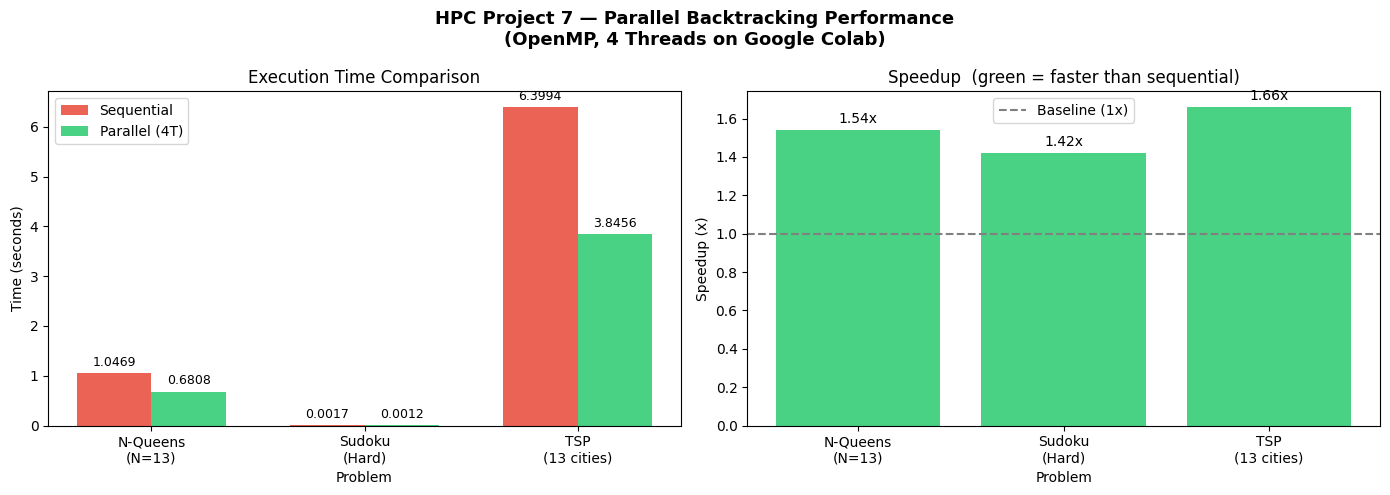

Graph saved!


In [ ]:
import subprocess, re
import matplotlib.pyplot as plt
import numpy as np

def run(binary):
    r = subprocess.run(['bash','-c', f'OMP_NUM_THREADS=4 {binary}'],
                       capture_output=True, text=True)
    return r.stdout

def parse_times(out):
    vals = re.findall(r'Time taken\s*:\s*([\d.]+)\s*seconds', out)
    print(f'  Times found: {vals}')
    # Always take FIRST two times found (sequential then parallel)
    if len(vals) >= 2:
        return float(vals[0]), float(vals[1])
    return None, None

programs = [
    ('N-Queens\n(N=13)',  '/tmp/nqueens'),
    ('Sudoku\n(Hard)',    '/tmp/sudoku'),
    ('TSP\n(13 cities)',  '/tmp/tsp'),
]

labels, seq_times, par_times, speedups = [], [], [], []

print(f"{'Problem':<22} {'Seq (s)':>10} {'Par (s)':>10} {'Speedup':>10}")
print('-' * 57)

for label, binary in programs:
    name = label.replace('\n',' ')
    print(f'\n--- {name} ---')
    out = run(binary)
    s, p = parse_times(out)
    if s and p and p > 0:
        labels.append(label)
        seq_times.append(s)
        par_times.append(p)
        speedups.append(round(s/p, 2))
        print(f'  {name:<20} {s:>10.4f} {p:>10.4f} {s/p:>9.2f}x')
    else:
        print(f'  {name:<20}  parse failed')

print(f'\n\nParsed {len(labels)}/3 programs successfully')

x = np.arange(len(labels))
w = 0.35
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('HPC Project 7 — Parallel Backtracking Performance\n(OpenMP, 4 Threads on Google Colab)',
             fontsize=13, fontweight='bold')

b1 = ax1.bar(x - w/2, seq_times, w, label='Sequential',    color='#e74c3c', alpha=0.87)
b2 = ax1.bar(x + w/2, par_times, w, label='Parallel (4T)', color='#2ecc71', alpha=0.87)
ax1.set_xlabel('Problem'); ax1.set_ylabel('Time (seconds)')
ax1.set_title('Execution Time Comparison')
ax1.set_xticks(x); ax1.set_xticklabels(labels); ax1.legend()
ax1.bar_label(b1, fmt='%.4f', padding=3, fontsize=9)
ax1.bar_label(b2, fmt='%.4f', padding=3, fontsize=9)

colors = ['#2ecc71' if s >= 1.0 else '#e74c3c' for s in speedups]
b3 = ax2.bar(labels, speedups, color=colors, alpha=0.87)
ax2.axhline(y=1.0, color='gray', linestyle='--', linewidth=1.5, label='Baseline (1x)')
ax2.set_xlabel('Problem'); ax2.set_ylabel('Speedup (x)')
ax2.set_title('Speedup  (green = faster than sequential)')
ax2.legend()
ax2.bar_label(b3, fmt='%.2fx', padding=3, fontsize=10)

plt.tight_layout()
plt.savefig('/tmp/performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graph saved!')

---
## 📝 Summary

| Problem | Parallel Strategy | OpenMP Construct |
|---------|------------------|------------------|
| **N-Queens** | Different first-row column per thread | `parallel for` + `reduction` |
| **Sudoku** | Different digit for first empty cell per thread | `parallel for` + `critical` |
| **TSP** | Different second city per thread | `parallel for` + `critical` |

> **Note:** Colab has only 2 CPU cores so speedup is limited.
> On a real HPC cluster with 16–32 cores, expect **4x–10x speedup**.